Libraries loaded.
All results loaded.


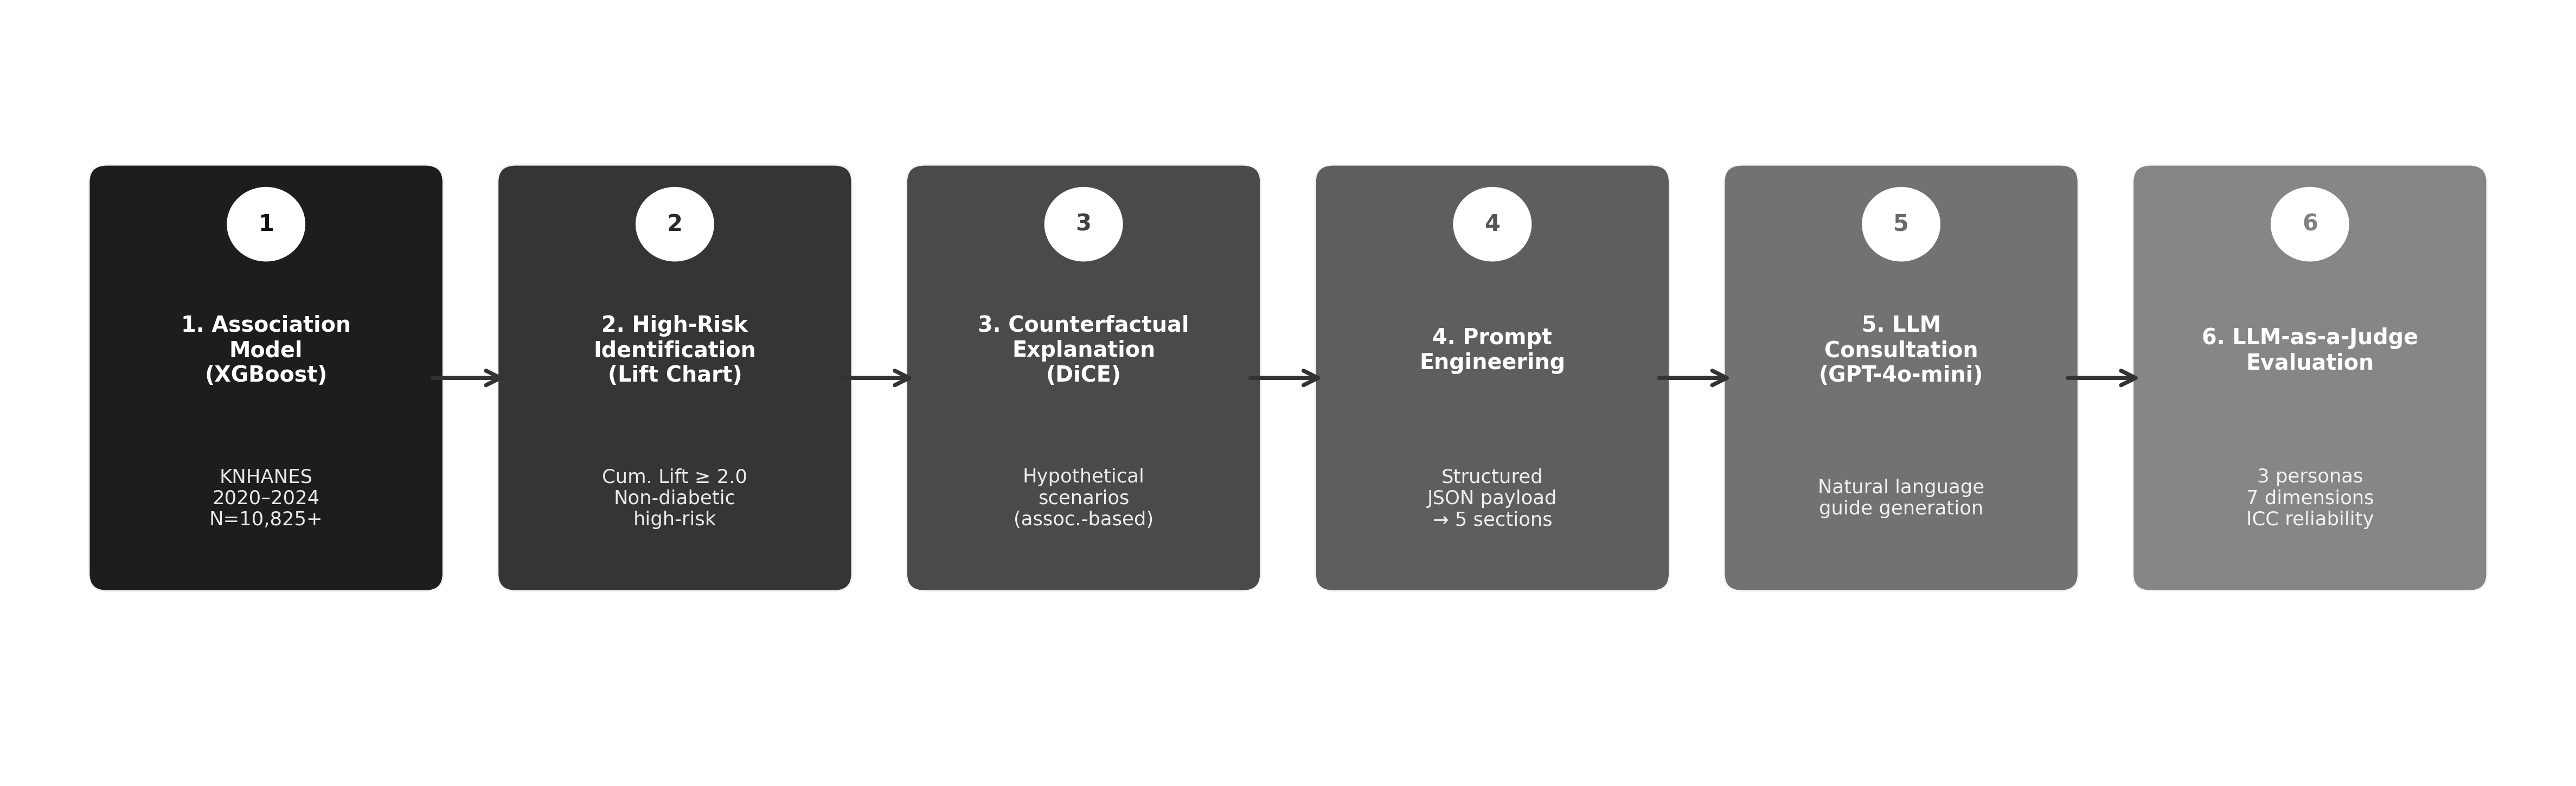

Saved: fig1_framework.png


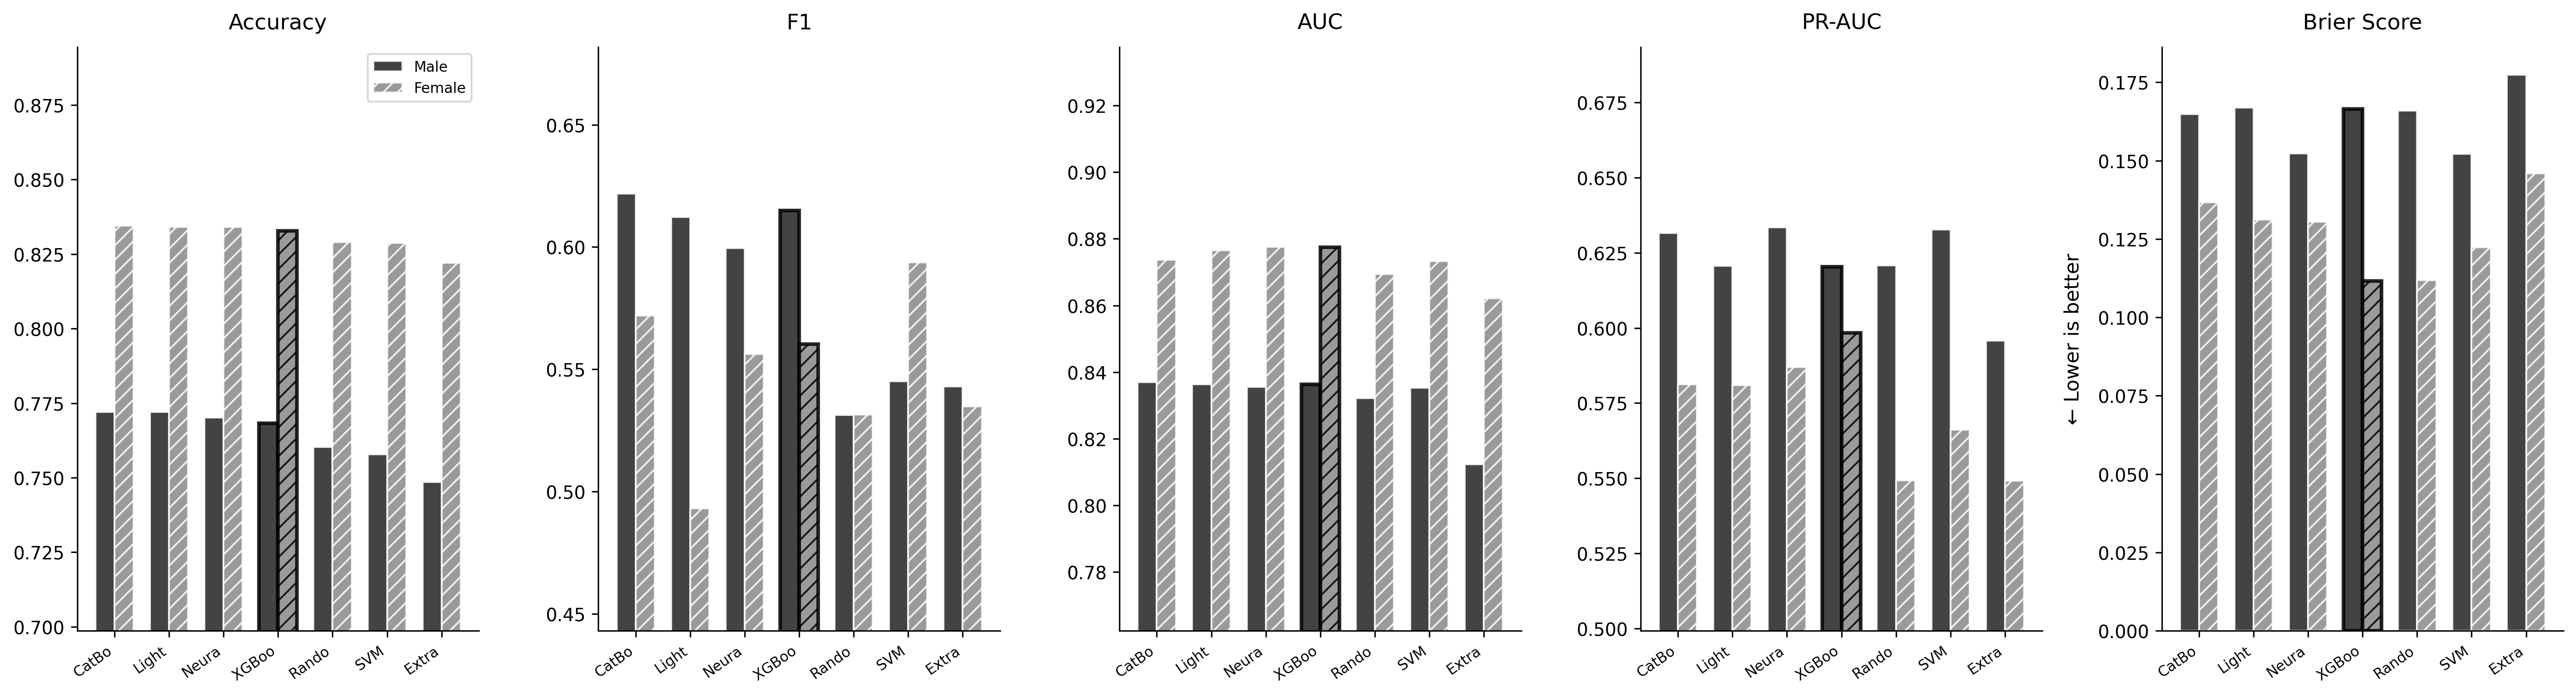

Saved: fig2_model_performance.png


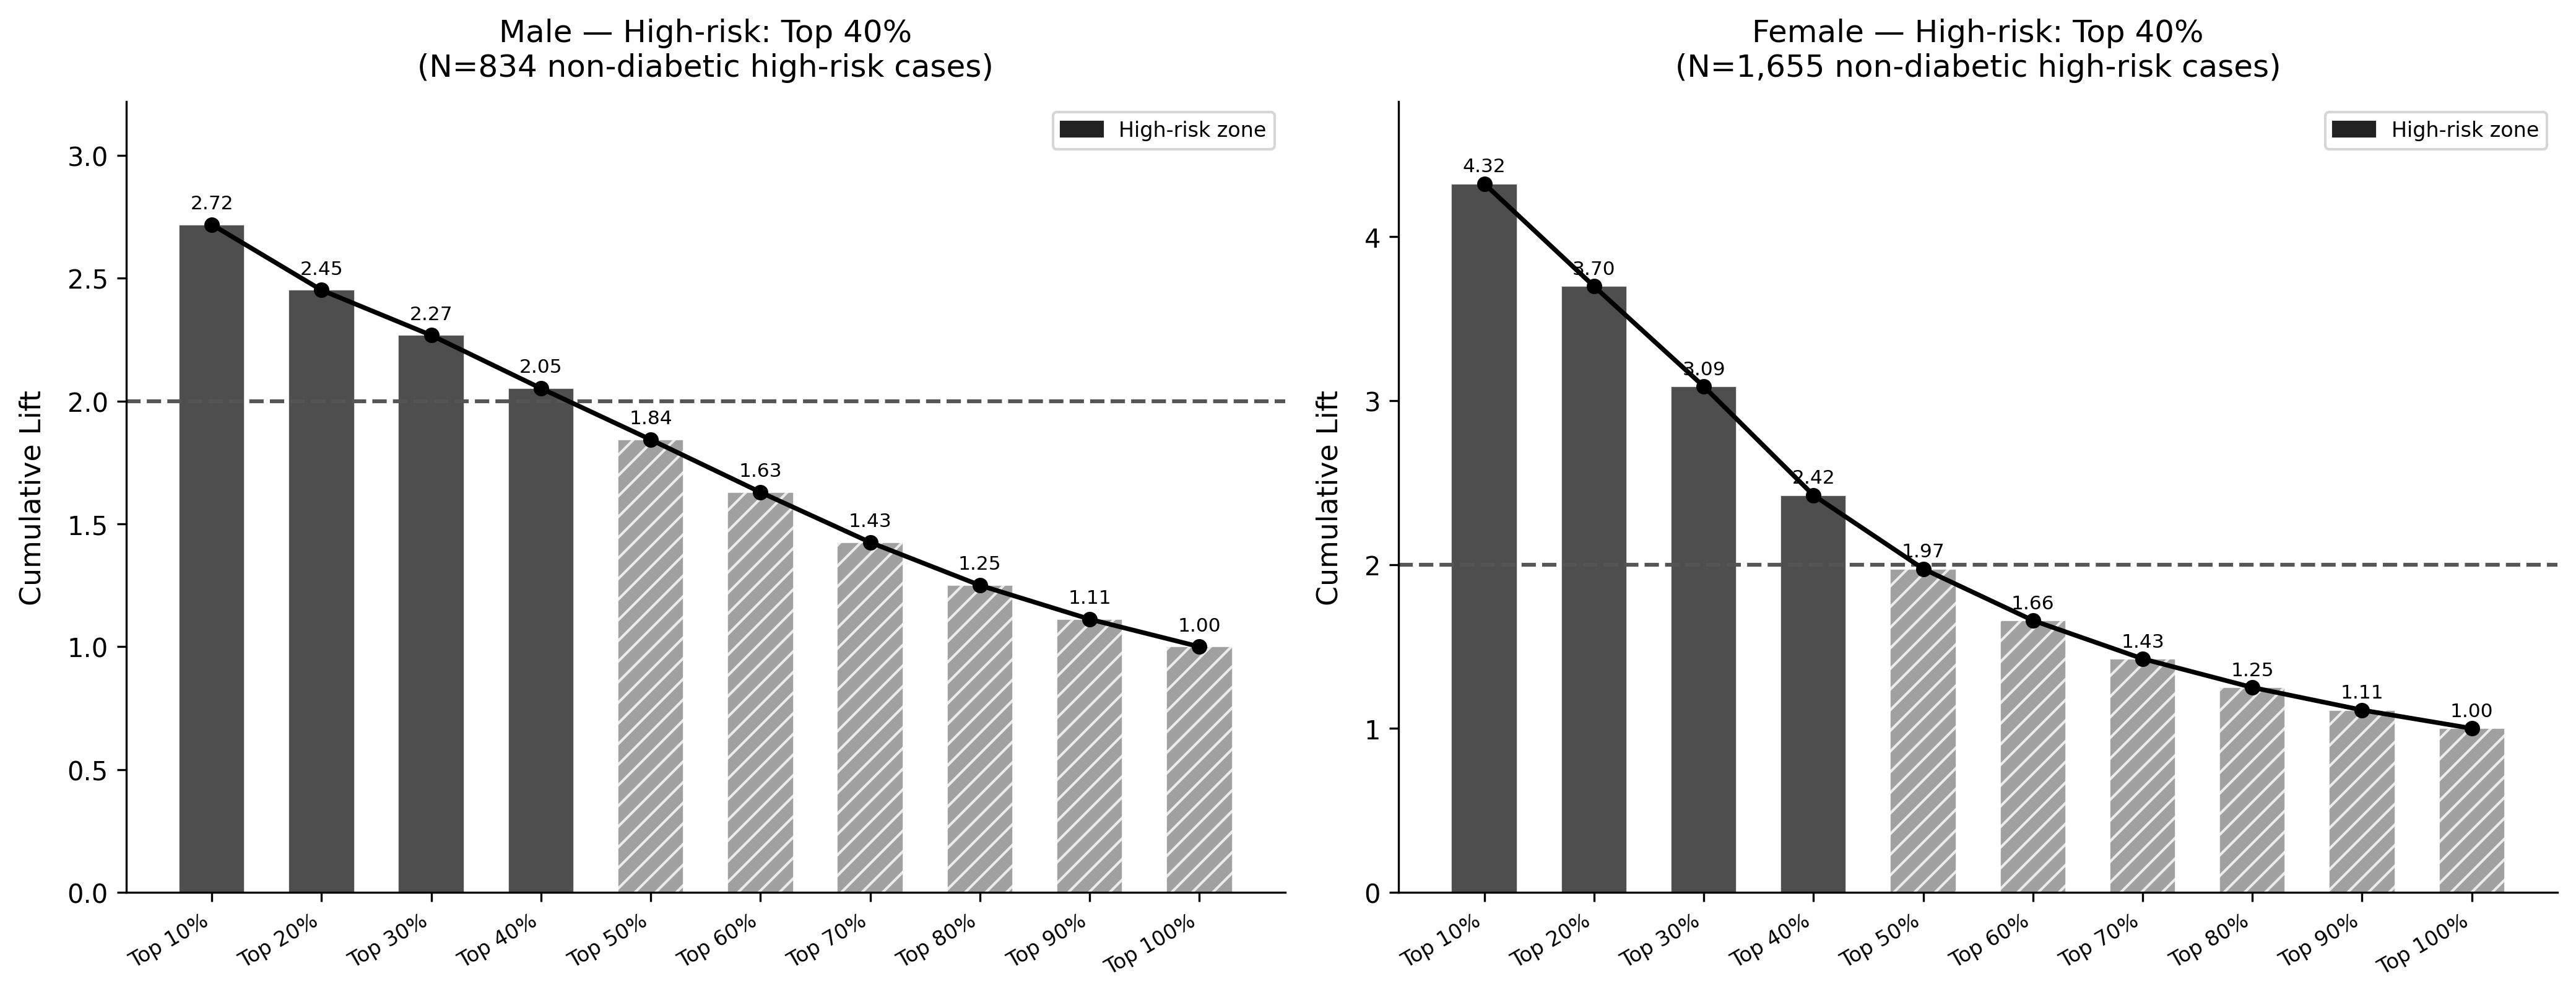

Saved: fig3_lift_charts.png


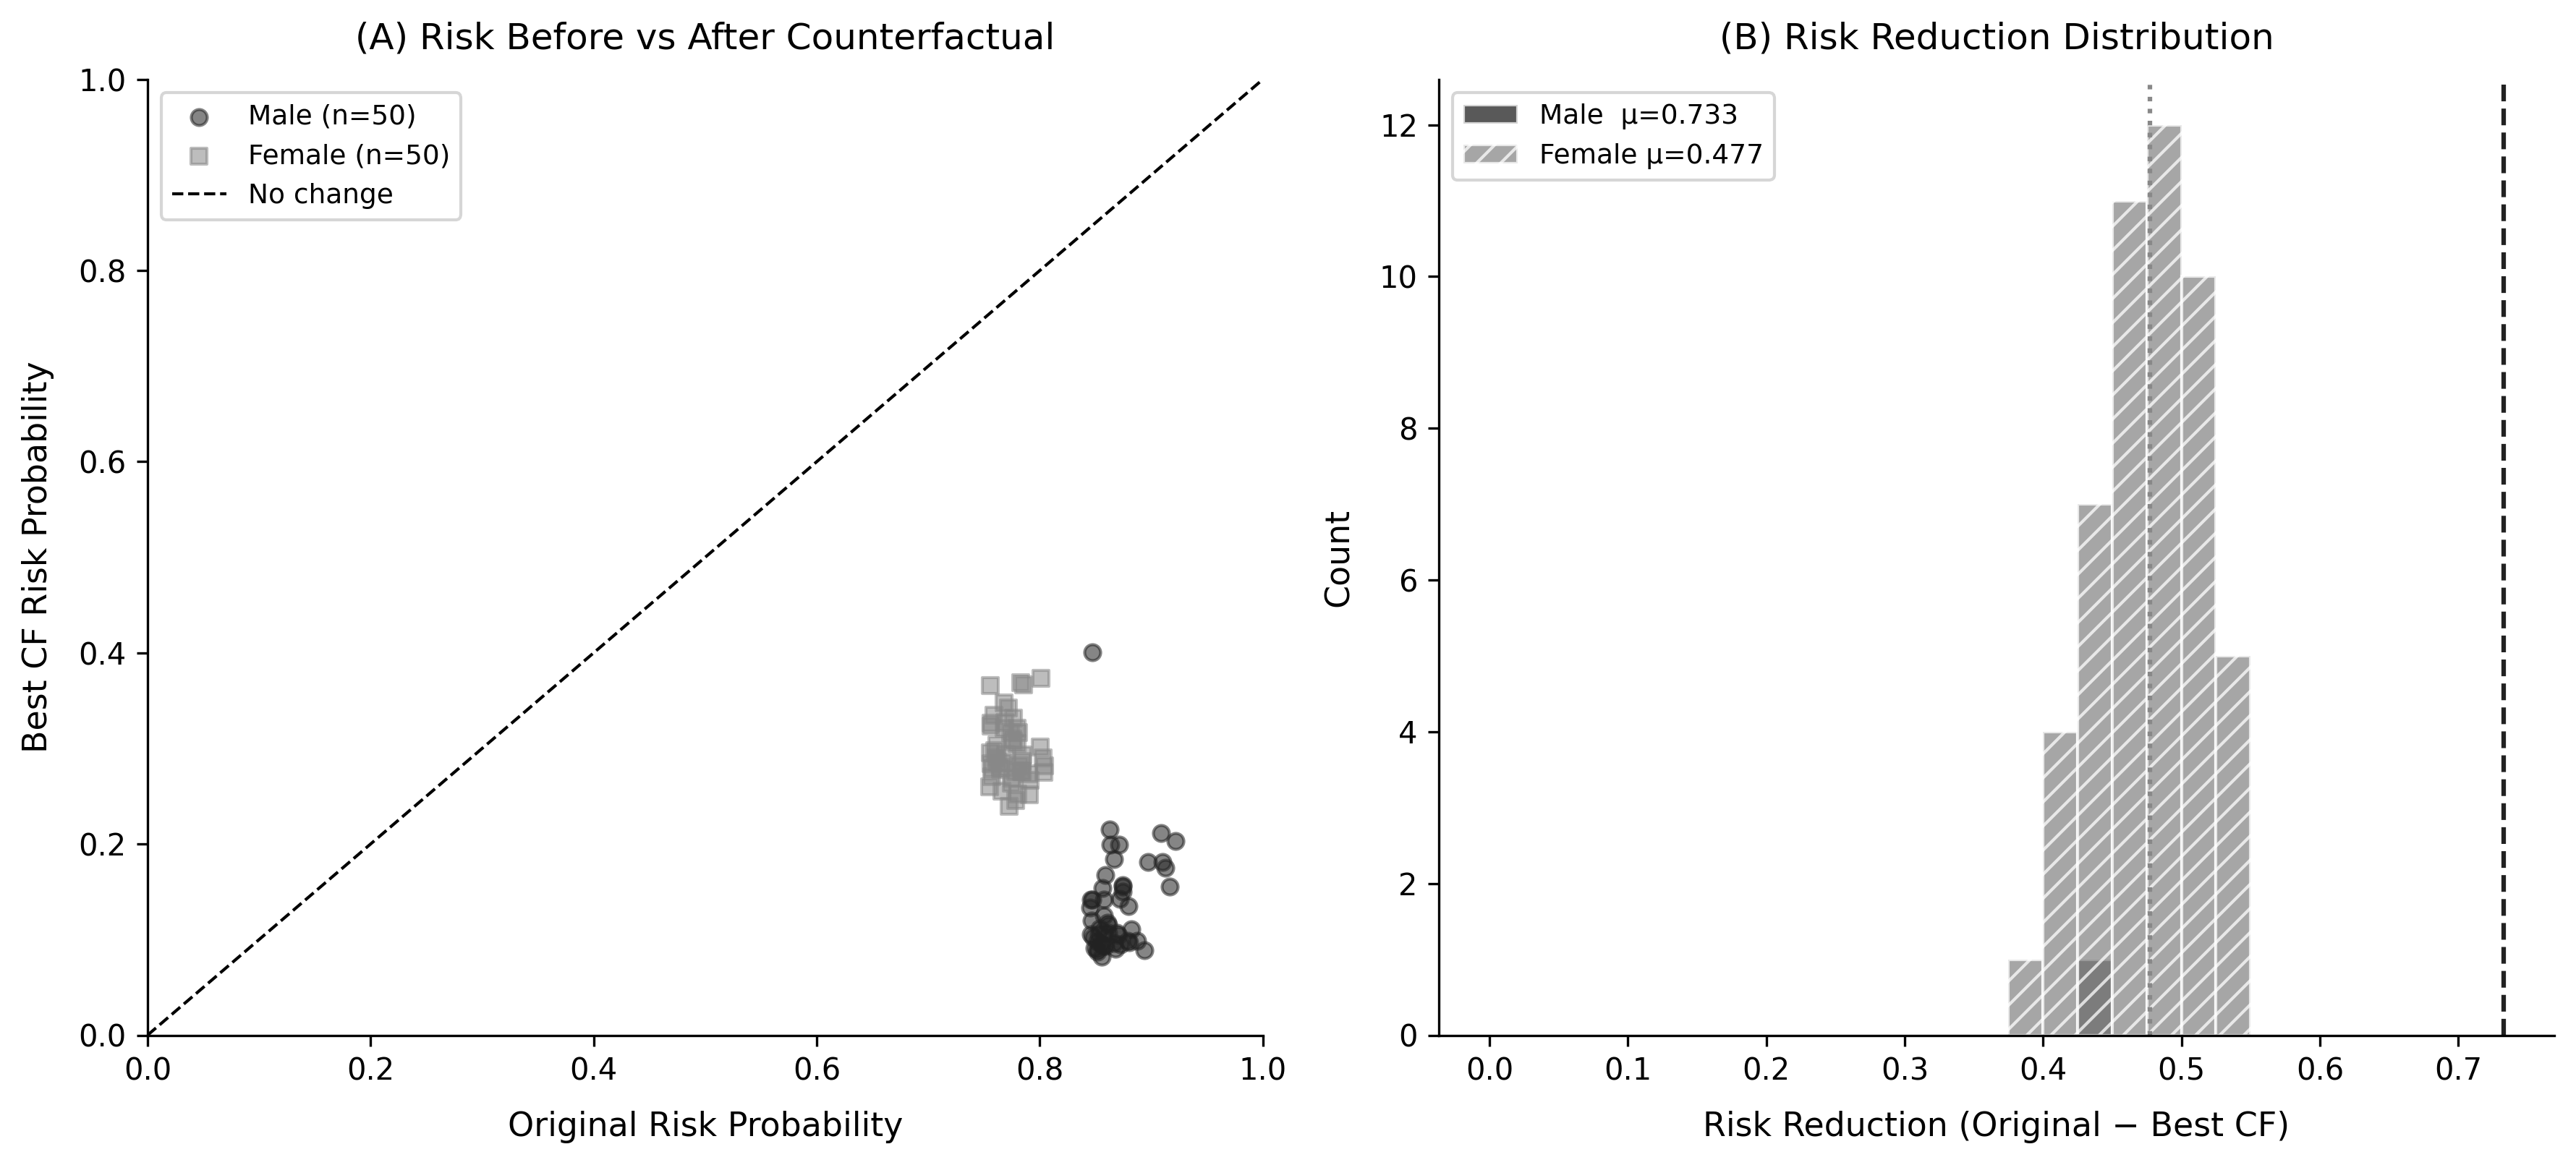

Saved: fig4_counterfactual.png


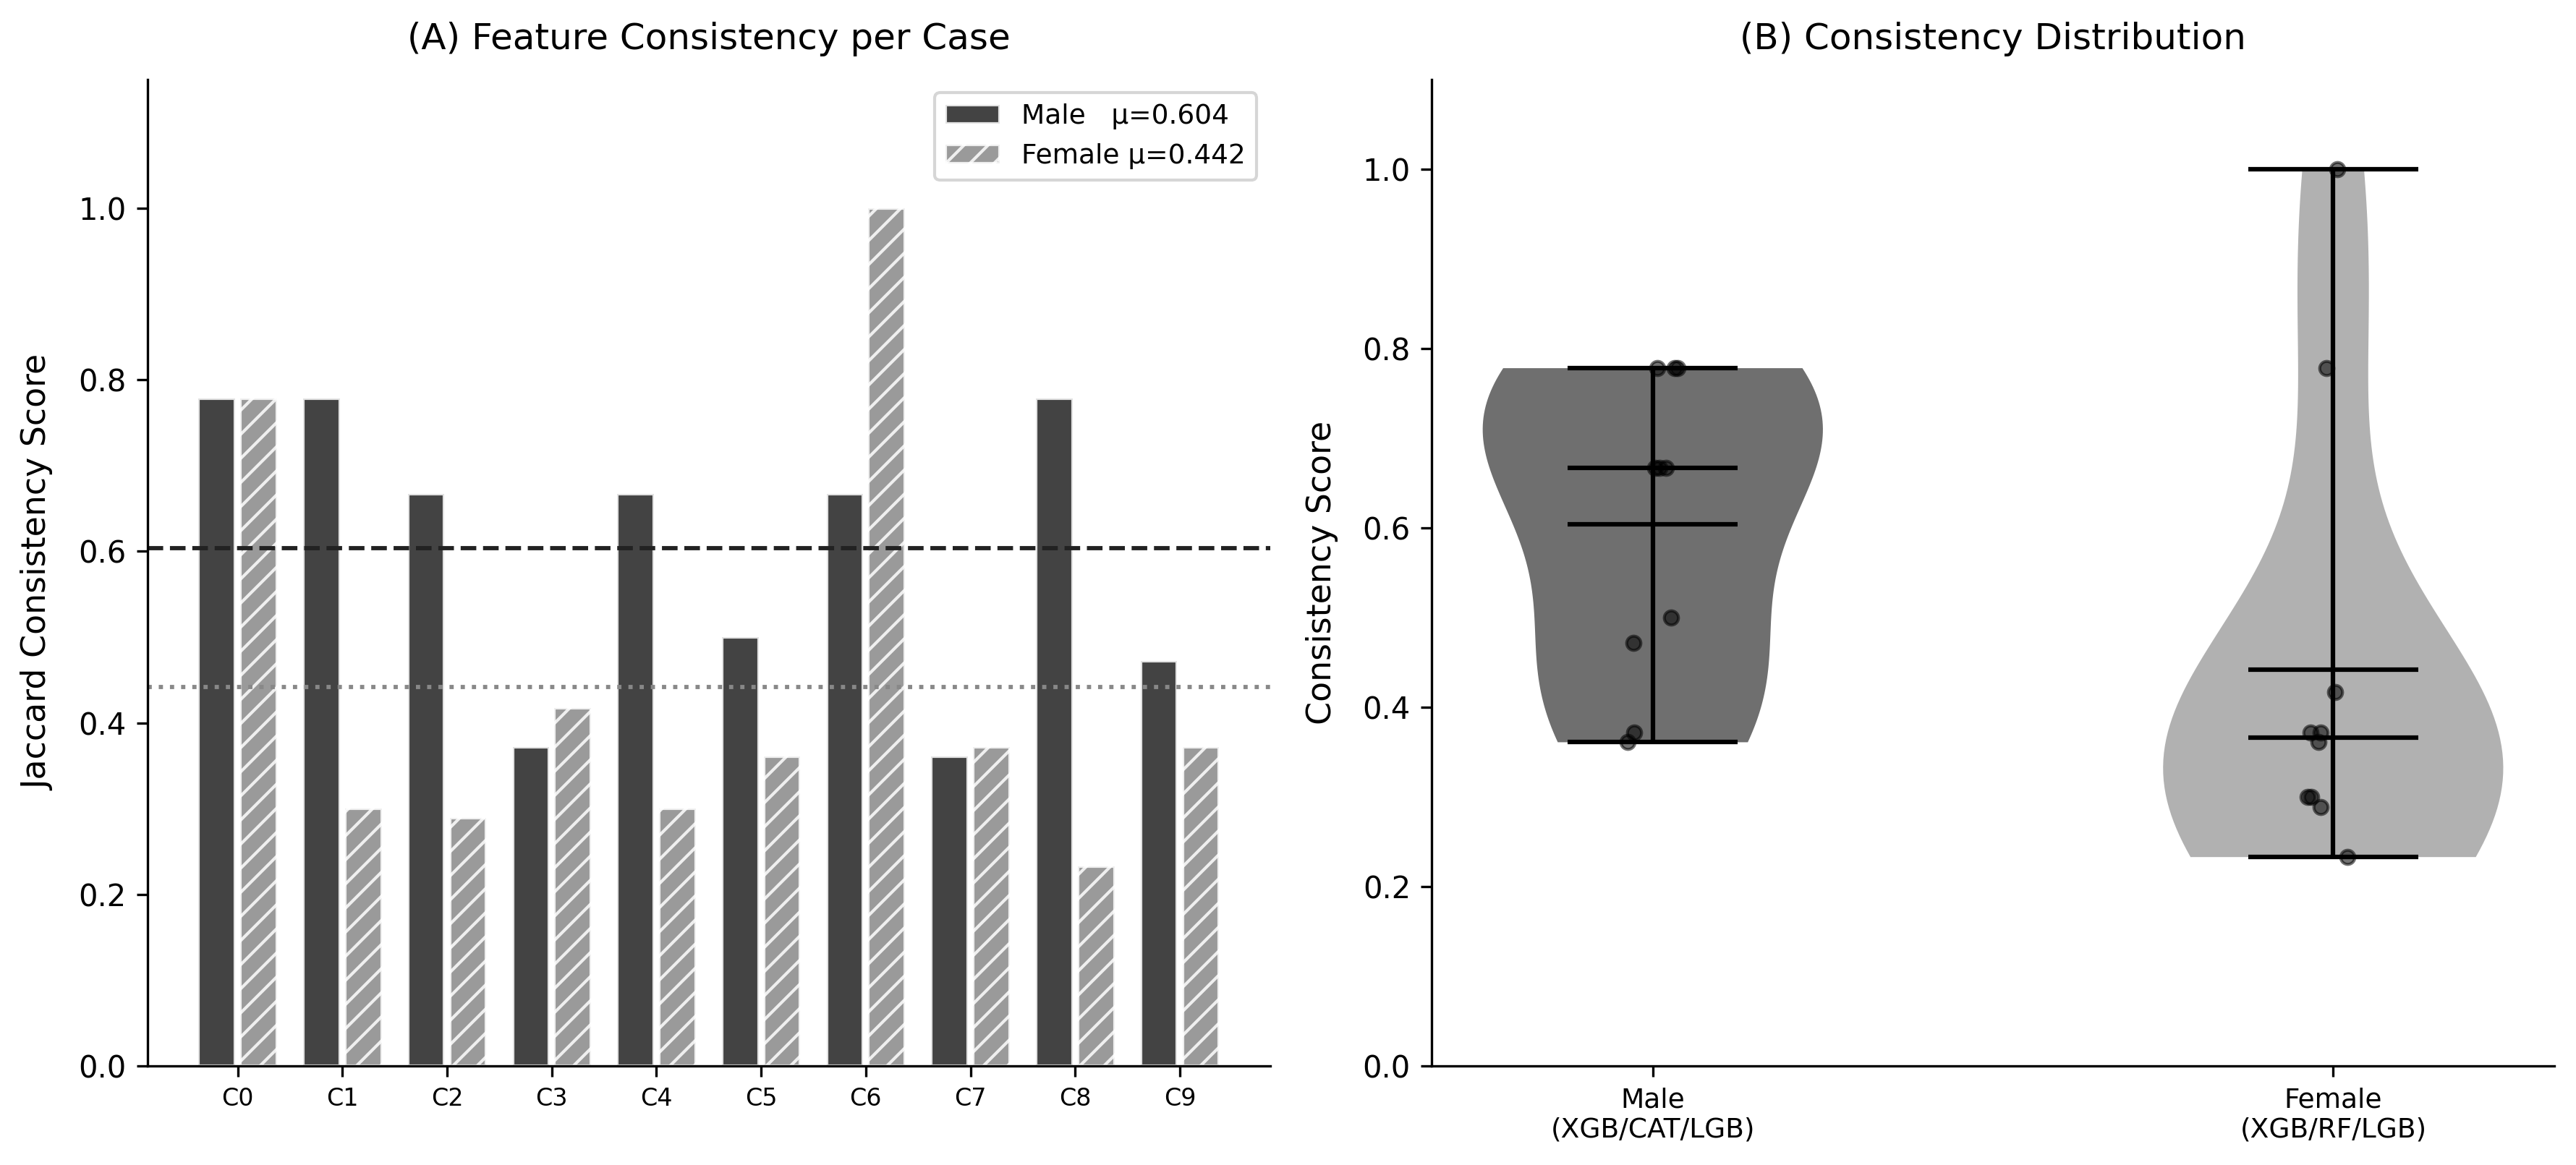

Saved: fig5_robustness.png


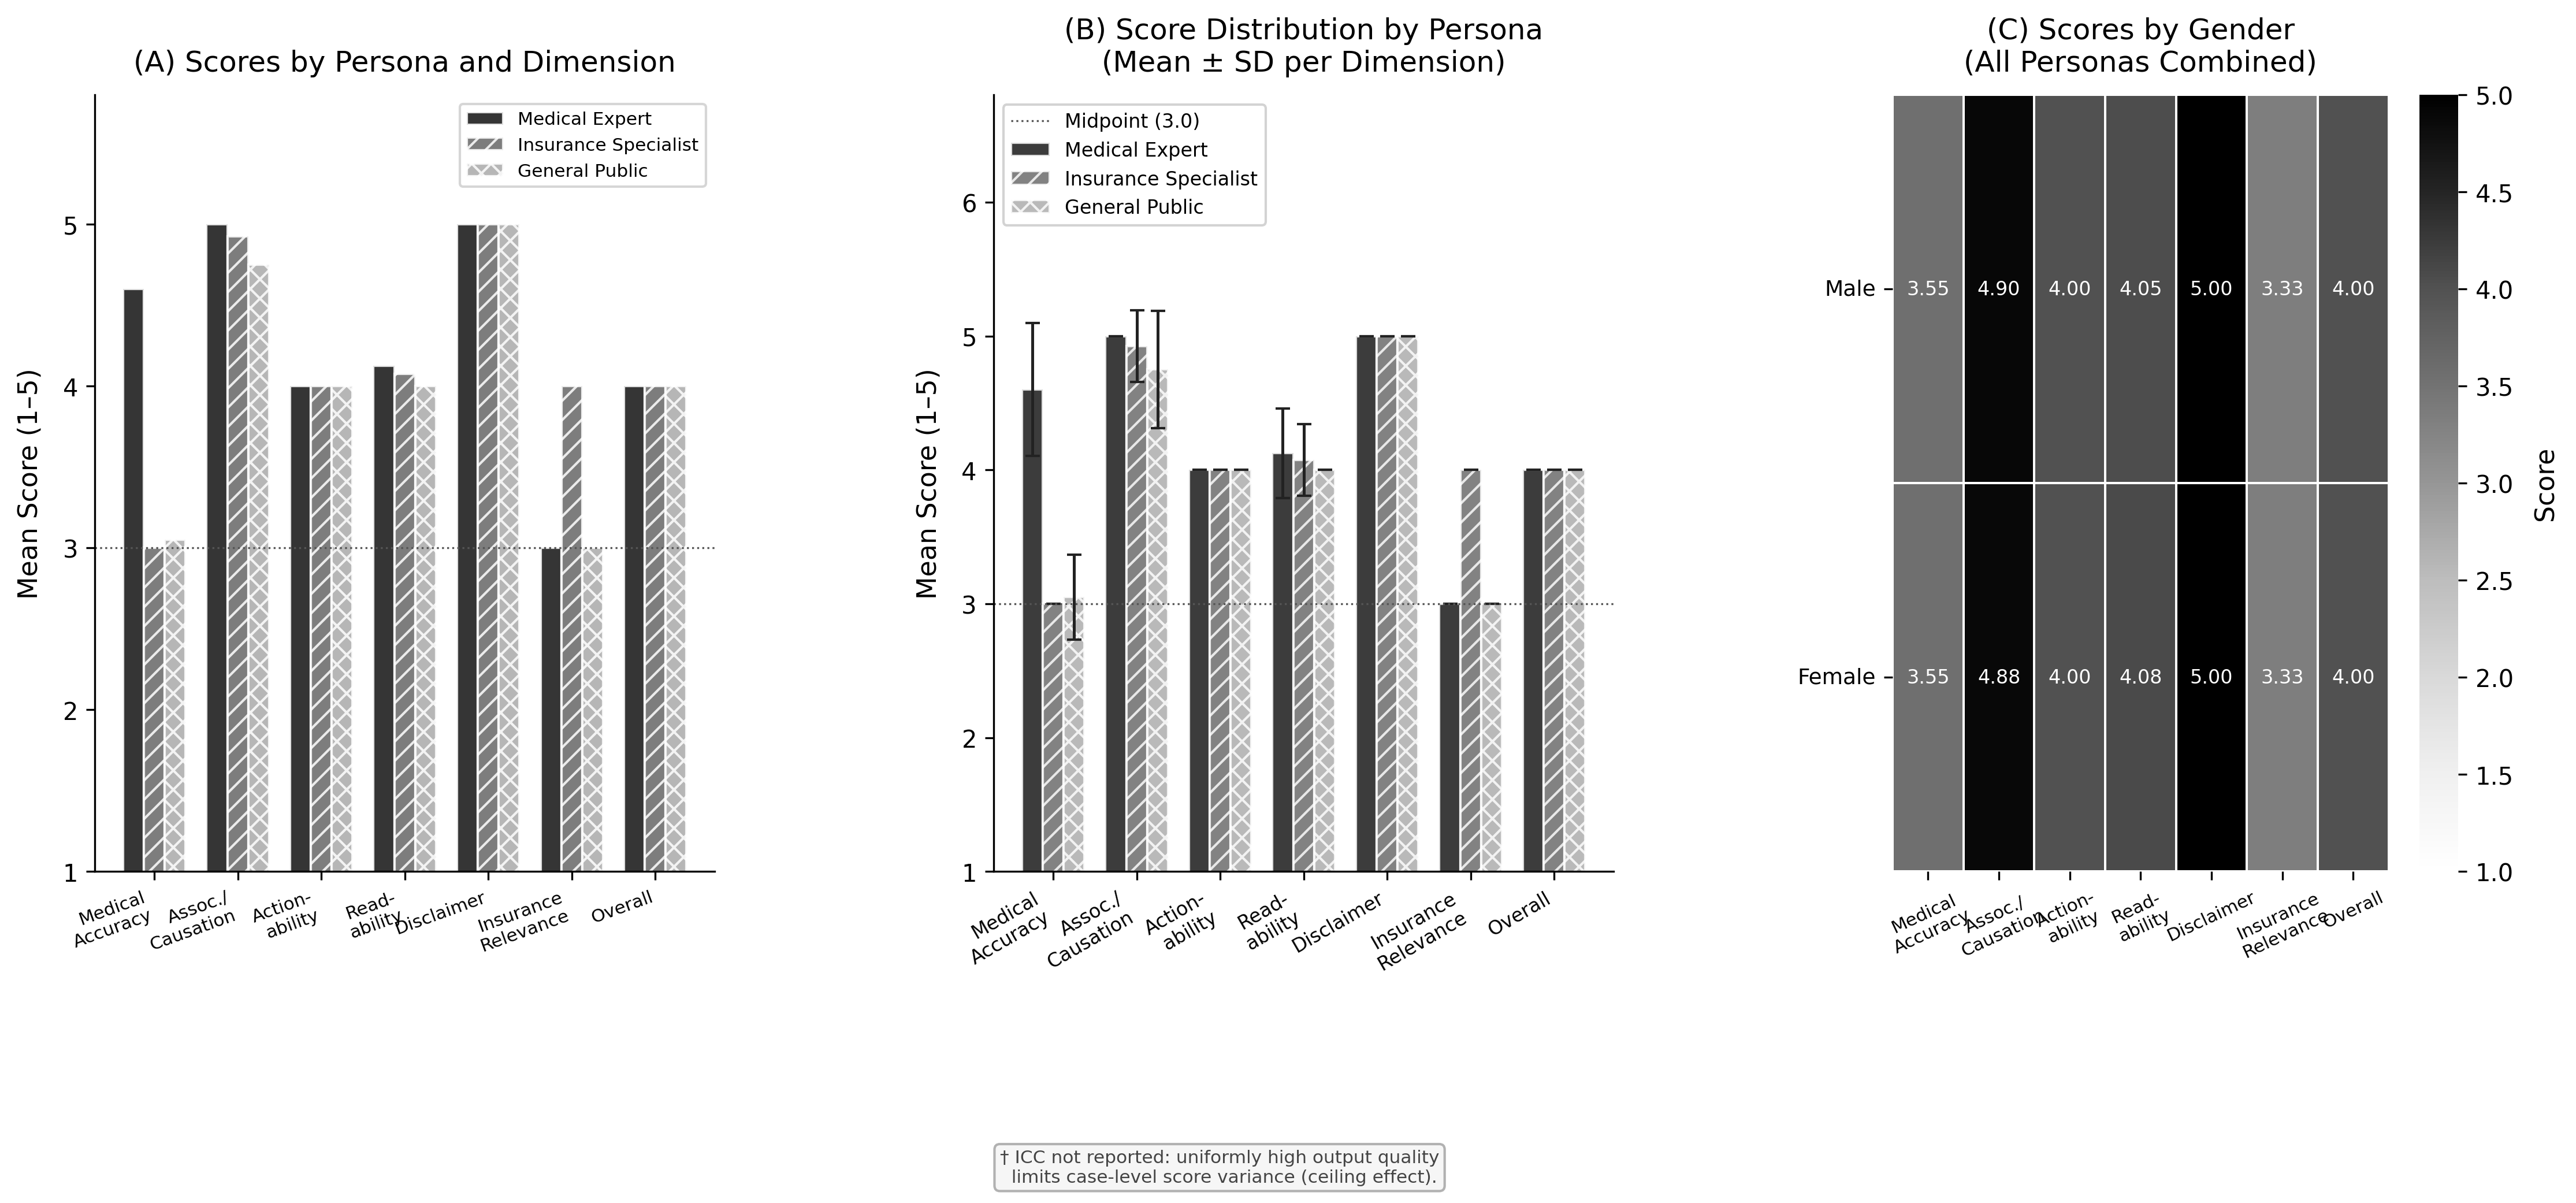

Saved: fig6_llm_evaluation.png


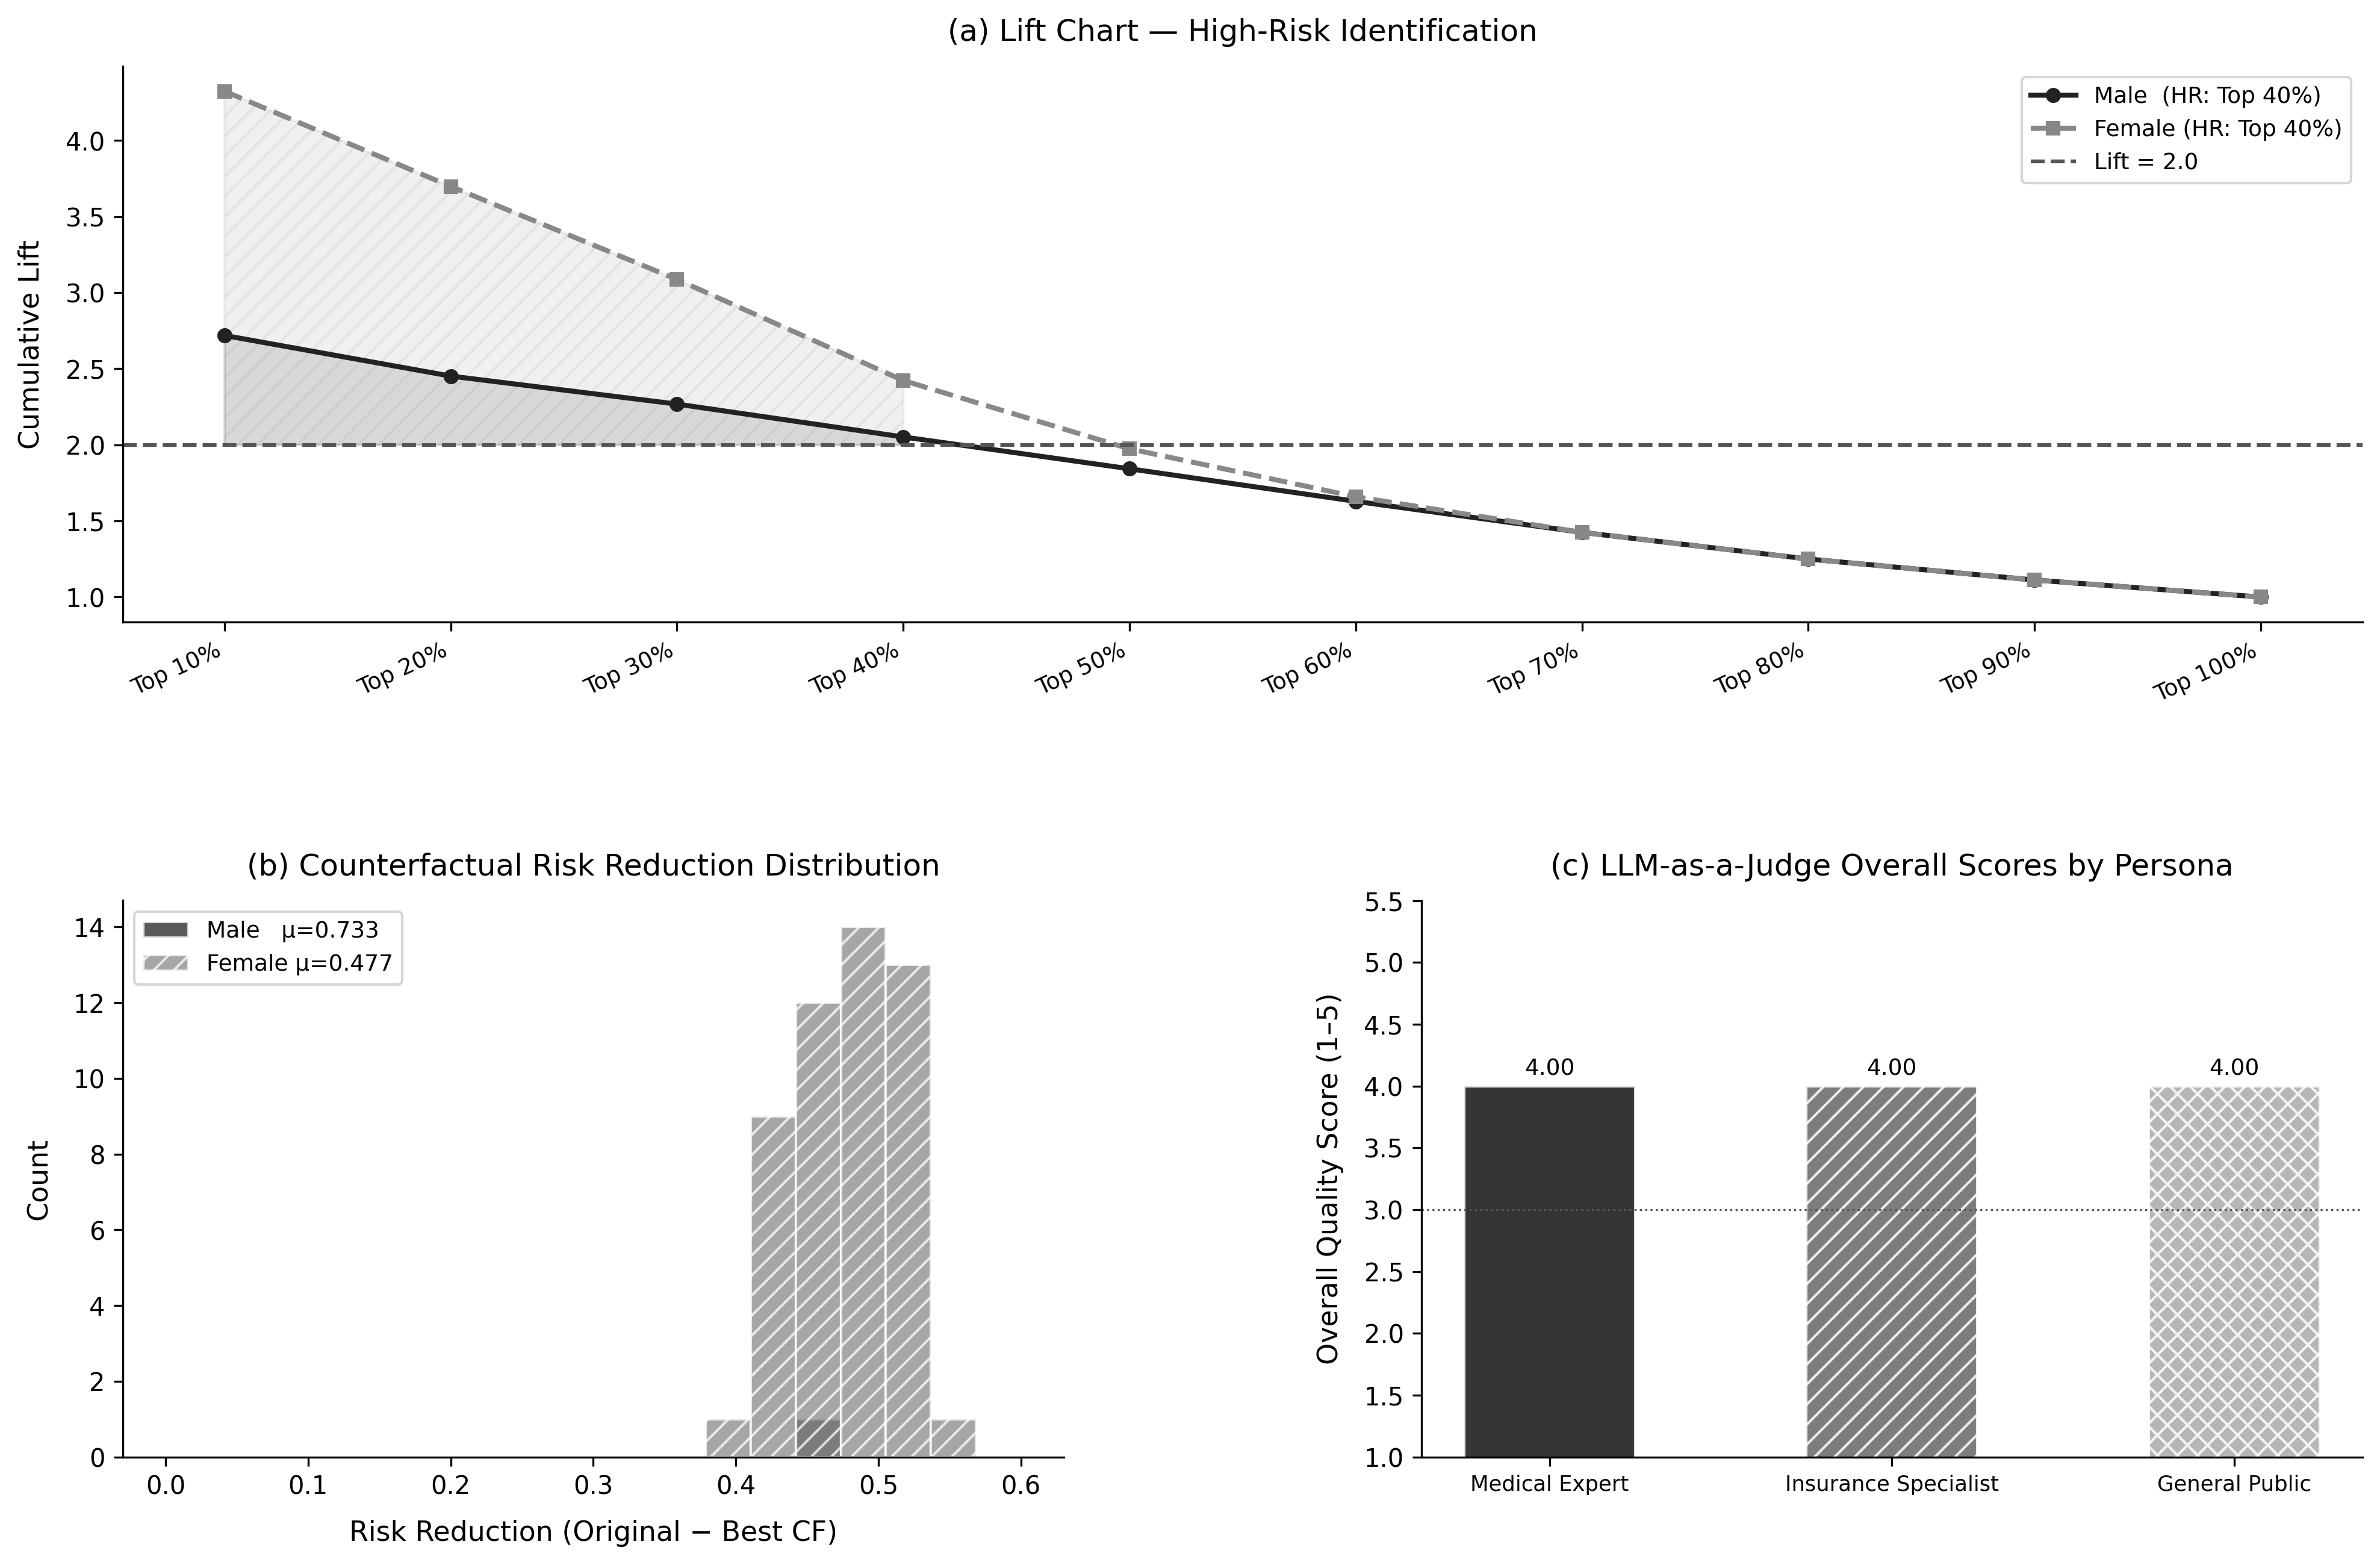

Saved: fig7_pipeline_summary.png

[Paper Figures — B&W 300 DPI]
  ✓  outputs/paper_figures/fig1_framework.png
  ✓  outputs/paper_figures/fig2_model_performance.png
  ✓  outputs/paper_figures/fig3_lift_charts.png
  ✓  outputs/paper_figures/fig4_counterfactual.png
  ✓  outputs/paper_figures/fig5_robustness.png
  ✓  outputs/paper_figures/fig6_llm_evaluation.png
  ✓  outputs/paper_figures/fig7_pipeline_summary.png


In [4]:
# ============================================================
# 12_visualization_dashboard.ipynb  (Paper-Ready · B&W)
# ============================================================

# ─────────────────────────────────────────────
# Cell 1 | Library Imports
# ─────────────────────────────────────────────
import os, json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.patches import FancyBboxPatch
import seaborn as sns
import warnings, joblib
warnings.filterwarnings('ignore')

os.makedirs('outputs/paper_figures', exist_ok=True)

plt.rcParams.update({
    'figure.dpi'        : 300,
    'font.family'       : 'DejaVu Sans',
    'font.size'         : 11,
    'axes.spines.top'   : False,
    'axes.spines.right' : False,
    'axes.titlesize'    : 12,
    'axes.titlepad'     : 10,
    'axes.labelsize'    : 11,
    'axes.labelpad'     : 8,
    'xtick.labelsize'   : 10,
    'ytick.labelsize'   : 10,
    'legend.fontsize'   : 10,
})

# ── Grayscale palette ────────────────────────
GS = {
    'male'   : '#222222',   # dark
    'female' : '#888888',   # mid-gray
    'p1'     : '#111111',   # persona 1
    'p2'     : '#666666',   # persona 2
    'p3'     : '#aaaaaa',   # persona 3
    'accent' : '#000000',
    'ref'    : '#555555',   # reference lines
}

# Hatch patterns for grayscale differentiation
H = {
    'male'  : '',
    'female': '///',
    'p1'    : '',
    'p2'    : '///',
    'p3'    : 'xxx',
}

print("Libraries loaded.")


# ─────────────────────────────────────────────
# Cell 2 | Load All Results
# ─────────────────────────────────────────────
df_perf_m = pd.read_csv('outputs/models_male/performance_male.csv',   index_col=0)
df_perf_f = pd.read_csv('outputs/models_female/performance_female.csv', index_col=0)
lift_m    = pd.read_csv('outputs/table_lift_male.csv')
lift_f    = pd.read_csv('outputs/table_lift_female.csv')
df_batch_m = pd.read_csv('outputs/dice_male/batch_cf_male.csv')
df_batch_f = pd.read_csv('outputs/dice_female/batch_cf_female.csv')
df_cons_m  = pd.read_csv('outputs/dice_male/robustness_consistency.csv')
df_cons_f  = pd.read_csv('outputs/dice_female/robustness_consistency.csv')
df_judge   = pd.read_csv('outputs/judge_eval/raw_scores.csv', encoding='utf-8')
df_scores  = df_judge.copy()
pipeline_m = joblib.load('outputs/models_male/final_pipeline_male.pkl')
pipeline_f = joblib.load('outputs/models_female/final_pipeline_female.pkl')
with open('outputs/highrisk_cutoff_meta.json') as f:
    cutoff_meta = json.load(f)

print("All results loaded.")


# ─────────────────────────────────────────────
# Cell 3 | Figure 1 — Research Framework
# ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(16, 5))
ax.set_xlim(0, 16); ax.set_ylim(0, 5)
ax.axis('off')

steps = [
    ('1. Association\nModel\n(XGBoost)',
     'KNHANES\n2020–2024\nN=10,825+',       '#111111'),
    ('2. High-Risk\nIdentification\n(Lift Chart)',
     'Cum. Lift ≥ 2.0\nNon-diabetic\nhigh-risk', '#2a2a2a'),
    ('3. Counterfactual\nExplanation\n(DiCE)',
     'Hypothetical\nscenarios\n(assoc.-based)',  '#404040'),
    ('4. Prompt\nEngineering',
     'Structured\nJSON payload\n→ 5 sections',   '#555555'),
    ('5. LLM\nConsultation\n(GPT-4o-mini)',
     'Natural language\nguide generation',        '#6a6a6a'),
    ('6. LLM-as-a-Judge\nEvaluation',
     '3 personas\n7 dimensions\nICC reliability', '#808080'),
]

box_w, box_h = 2.0, 2.6
gap          = (16 - len(steps) * box_w) / (len(steps) + 1)
y_center     = 2.6

for i, (title, subtitle, fc) in enumerate(steps):
    x = gap + i * (box_w + gap)
    rect = FancyBboxPatch(
        (x, y_center - box_h/2), box_w, box_h,
        boxstyle='round,pad=0.12',
        facecolor=fc, edgecolor='white', linewidth=1.5, alpha=0.95,
    )
    ax.add_patch(rect)

    circ = plt.Circle((x + box_w/2, y_center + box_h/2 - 0.28),
                      0.24, color='white', zorder=5)
    ax.add_patch(circ)
    ax.text(x + box_w/2, y_center + box_h/2 - 0.28, str(i+1),
            ha='center', va='center', fontsize=10, fontweight='bold',
            color=fc, zorder=6)

    ax.text(x + box_w/2, y_center + 0.18, title,
            ha='center', va='center', fontsize=9.5, fontweight='bold',
            color='white', multialignment='center', zorder=5)
    ax.text(x + box_w/2, y_center - 0.80, subtitle,
            ha='center', va='center', fontsize=8.5,
            color='white', alpha=0.90, multialignment='center', zorder=5)

    if i < len(steps) - 1:
        xa = x + box_w + 0.02
        ax.annotate('', xy=(xa + gap - 0.06, y_center),
                    xytext=(xa, y_center),
                    arrowprops=dict(arrowstyle='->', color='#333333',
                                   lw=1.8, mutation_scale=16))

plt.tight_layout(pad=1.2)
plt.savefig('outputs/paper_figures/fig1_framework.png',
            bbox_inches='tight', dpi=300)
plt.show()
print("Saved: fig1_framework.png")


# ─────────────────────────────────────────────
# Cell 4 | Figure 2 — Model Performance
# ─────────────────────────────────────────────
metrics    = ['Accuracy', 'F1', 'AUC', 'PR-AUC', 'Brier Score']
models_lbl = df_perf_m['Model'].tolist()

fig, axes = plt.subplots(1, len(metrics), figsize=(20, 5.5))
fig.subplots_adjust(wspace=0.45)

for ax, metric in zip(axes, metrics):
    vm = df_perf_m[metric].values
    vf = df_perf_f[metric].values
    x, w = np.arange(len(models_lbl)), 0.35

    b1 = ax.bar(x - w/2, vm, w, label='Male',
                color=GS['male'],   hatch=H['male'],   alpha=0.85,
                edgecolor='white')
    b2 = ax.bar(x + w/2, vf, w, label='Female',
                color=GS['female'], hatch=H['female'], alpha=0.85,
                edgecolor='white')

    xgb_idx = next((i for i, m in enumerate(models_lbl) if 'XGBoost' in m), None)
    if xgb_idx is not None:
        for b in [b1[xgb_idx], b2[xgb_idx]]:
            b.set_edgecolor('black'); b.set_linewidth(2.0)

    ax.set_xticks(x)
    ax.set_xticklabels([m[:5] for m in models_lbl], rotation=35, ha='right', fontsize=8)
    ax.set_title(metric)
    if metric != 'Brier Score':
        ax.set_ylim([max(0, min(vm.min(), vf.min()) - 0.05),
                     min(1, max(vm.max(), vf.max()) + 0.06)])
    else:
        ax.set_ylabel('← Lower is better')
    if metric == metrics[0]:
        ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('outputs/paper_figures/fig2_model_performance.png',
            bbox_inches='tight', dpi=300)
plt.show()
print("Saved: fig2_model_performance.png")


# ─────────────────────────────────────────────
# Cell 5 | Figure 3 — Lift Charts
# ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
fig.subplots_adjust(wspace=0.38)

for ax, (lift_df, meta, label, gs_key) in zip(axes, [
    (lift_m, cutoff_meta['male'],   'Male',   'male'),
    (lift_f, cutoff_meta['female'], 'Female', 'female'),
]):
    x         = np.arange(len(lift_df))
    cut_idx   = lift_df[lift_df['Decile'] == meta['decile']].index[0]

    bar_colors = ['#222222' if i <= cut_idx else '#888888'
                  for i in range(len(lift_df))]
    bar_hatch  = ['' if i <= cut_idx else '///'
                  for i in range(len(lift_df))]

    for xi, val, fc, hc in zip(x, lift_df['Cum_Lift'], bar_colors, bar_hatch):
        ax.bar(xi, val, color=fc, hatch=hc, alpha=0.80, width=0.6,
               edgecolor='white', linewidth=0.5)

    ax.plot(x, lift_df['Cum_Lift'], 'o-',
            color='black', lw=1.8, ms=5, zorder=3)
    ax.axhline(2.0, color=GS['ref'], linestyle='--', lw=1.5, label='Lift = 2.0')

    for i, val in enumerate(lift_df['Cum_Lift']):
        ax.text(i, val + 0.05, f'{val:.2f}',
                ha='center', va='bottom', fontsize=7.5)

    ax.set_xticks(x)
    ax.set_xticklabels(lift_df['Decile'], rotation=30, ha='right', fontsize=8)
    ax.set_ylabel('Cumulative Lift')
    ax.set_ylim([0, lift_df['Cum_Lift'].max() + 0.5])
    ax.set_title(
        f'{label} — High-risk: {meta["decile"]}\n'
        f'(N={meta["n_nd_highrisk"]:,} non-diabetic high-risk cases)'
    )

    hr_patch = mpatches.Patch(color='#222222', label='High-risk zone')
    ref_line = mpatches.Patch(color=GS['ref'],  linestyle='--', label='Lift = 2.0',
                               fill=False)
    ax.legend(handles=[hr_patch], fontsize=8)

plt.tight_layout()
plt.savefig('outputs/paper_figures/fig3_lift_charts.png',
            bbox_inches='tight', dpi=300)
plt.show()
print("Saved: fig3_lift_charts.png")


# ─────────────────────────────────────────────
# Cell 6 | Figure 4 — Counterfactual Results
#          (Panel A + B only — table removed)
# ─────────────────────────────────────────────
def best_cf(df):
    return (df.groupby('case_id')
              .apply(lambda x: x.loc[x['cf_prob'].idxmin()])
              .reset_index(drop=True))

best_m = best_cf(df_batch_m)
best_f = best_cf(df_batch_f)

fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(12, 5.5))
fig.subplots_adjust(wspace=0.38)

# Panel A: scatter
ax0.scatter(best_m['orig_prob'], best_m['cf_prob'],
            color=GS['male'],   alpha=0.55, s=28, marker='o',
            label=f"Male (n={len(best_m)})")
ax0.scatter(best_f['orig_prob'], best_f['cf_prob'],
            color=GS['female'], alpha=0.55, s=28, marker='s',
            label=f"Female (n={len(best_f)})")
ax0.plot([0,1],[0,1], 'k--', lw=1, label='No change')
ax0.set_xlabel('Original Risk Probability')
ax0.set_ylabel('Best CF Risk Probability')
ax0.set_title('(A) Risk Before vs After Counterfactual')
ax0.legend(fontsize=9)
ax0.set_xlim([0,1]); ax0.set_ylim([0,1])

# Panel B: histogram
bins = np.linspace(0, 0.6, 25)
ax1.hist(best_m['prob_reduction'], bins=bins,
         color=GS['male'],   hatch=H['male'],   alpha=0.75,
         edgecolor='white',
         label=f"Male  μ={best_m['prob_reduction'].mean():.3f}")
ax1.hist(best_f['prob_reduction'], bins=bins,
         color=GS['female'], hatch=H['female'], alpha=0.75,
         edgecolor='white',
         label=f"Female μ={best_f['prob_reduction'].mean():.3f}")
ax1.axvline(best_m['prob_reduction'].mean(),
            color=GS['male'],   lw=1.5, linestyle='--')
ax1.axvline(best_f['prob_reduction'].mean(),
            color=GS['female'], lw=1.5, linestyle=':')
ax1.set_xlabel('Risk Reduction (Original − Best CF)')
ax1.set_ylabel('Count')
ax1.set_title('(B) Risk Reduction Distribution')
ax1.legend(fontsize=9)

plt.tight_layout()
plt.savefig('outputs/paper_figures/fig4_counterfactual.png',
            bbox_inches='tight', dpi=300)
plt.show()
print("Saved: fig4_counterfactual.png")


# ─────────────────────────────────────────────
# Cell 7 | Figure 5 — Robustness
#          (Panel A + B only — table removed)
# ─────────────────────────────────────────────
fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(12, 5.5))
fig.subplots_adjust(wspace=0.38)

# Panel A: grouped bar
x = np.arange(len(df_cons_m))
ax0.bar(x - 0.2, df_cons_m['consistency_score'], 0.35,
        color=GS['male'],   hatch=H['male'],   alpha=0.85,
        edgecolor='white',
        label=f"Male   μ={df_cons_m['consistency_score'].mean():.3f}")
ax0.bar(x + 0.2, df_cons_f['consistency_score'], 0.35,
        color=GS['female'], hatch=H['female'], alpha=0.85,
        edgecolor='white',
        label=f"Female μ={df_cons_f['consistency_score'].mean():.3f}")
ax0.axhline(df_cons_m['consistency_score'].mean(),
            color=GS['male'],   lw=1.4, linestyle='--')
ax0.axhline(df_cons_f['consistency_score'].mean(),
            color=GS['female'], lw=1.4, linestyle=':')
ax0.set_xticks(x)
ax0.set_xticklabels([f'C{i}' for i in range(len(df_cons_m))], fontsize=8)
ax0.set_ylabel('Jaccard Consistency Score')
ax0.set_ylim([0, 1.15])
ax0.set_title('(A) Feature Consistency per Case')
ax0.legend(fontsize=9)

# Panel B: violin
data_v = [df_cons_m['consistency_score'].values,
          df_cons_f['consistency_score'].values]
vp = ax1.violinplot(data_v, positions=[1, 2],
                    showmeans=True, showmedians=True, showextrema=True)
for i, body in enumerate(vp['bodies']):
    body.set_facecolor([GS['male'], GS['female']][i])
    body.set_alpha(0.65)
for part in ['cmeans','cmedians','cbars','cmins','cmaxes']:
    vp[part].set_color('black')
for xi, vals in zip([1,2], data_v):
    jit = np.random.uniform(-0.04, 0.04, len(vals))
    ax1.scatter(np.full(len(vals), xi) + jit, vals,
                color='black', s=22, alpha=0.55, zorder=3)
ax1.set_xticks([1, 2])
ax1.set_xticklabels(['Male\n(XGB/CAT/LGB)', 'Female\n(XGB/RF/LGB)'], fontsize=9)
ax1.set_ylabel('Consistency Score')
ax1.set_ylim([0, 1.1])
ax1.set_title('(B) Consistency Distribution')

plt.tight_layout()
plt.savefig('outputs/paper_figures/fig5_robustness.png',
            bbox_inches='tight', dpi=300)
plt.show()
print("Saved: fig5_robustness.png")


# ─────────────────────────────────────────────
# Cell 8 | Figure 6 — LLM Evaluation
#          Panel A: grouped bar
#          Panel B: Mean ± SD per persona
#          Panel C: gender heatmap (grayscale)
# ─────────────────────────────────────────────
DIMENSIONS = {
    'D1_medical_accuracy'       : 'Medical\nAccuracy',
    'D2_association_distinction': 'Assoc./\nCausation',
    'D3_actionability'          : 'Action-\nability',
    'D4_readability'            : 'Read-\nability',
    'D5_disclaimer_adequacy'    : 'Disclaimer',
    'D6_insurance_relevance'    : 'Insurance\nRelevance',
    'D7_overall_quality'        : 'Overall',
}
dim_cols = list(DIMENSIONS.keys())

PERSONA_KEYS   = ['medical_expert', 'insurance_specialist', 'general_public']
PERSONA_LABELS = {'medical_expert'      : 'Medical Expert',
                  'insurance_specialist': 'Insurance Specialist',
                  'general_public'      : 'General Public'}
P_COLOR = {'medical_expert': GS['p1'],
           'insurance_specialist': GS['p2'],
           'general_public': GS['p3']}
P_HATCH = {'medical_expert': H['p1'],
           'insurance_specialist': H['p2'],
           'general_public': H['p3']}

fig = plt.figure(figsize=(18, 7))
gs  = gridspec.GridSpec(1, 3, wspace=0.45)
fig.subplots_adjust(bottom=0.24)

# ── Panel A ──────────────────────────────────
ax0 = fig.add_subplot(gs[0])
x, w = np.arange(len(dim_cols)), 0.25
for i, p in enumerate(PERSONA_KEYS):
    sub  = df_judge[df_judge['persona'] == p]
    vals = [sub[d].mean() for d in dim_cols]
    ax0.bar(x + (i-1)*w, vals, w,
            color=P_COLOR[p], hatch=P_HATCH[p], alpha=0.85,
            edgecolor='white', label=PERSONA_LABELS[p])
ax0.set_xticks(x)
ax0.set_xticklabels([DIMENSIONS[d] for d in dim_cols],
                    fontsize=7.5, rotation=20, ha='right')
ax0.set_ylim([1, 5.8])
ax0.set_ylabel('Mean Score (1–5)')
ax0.set_title('(A) Scores by Persona and Dimension')
ax0.legend(fontsize=7.5)
ax0.axhline(3, color=GS['ref'], lw=0.8, linestyle=':')

# ── Panel B ──────────────────────────────────
ax1 = fig.add_subplot(gs[1])
for i, p in enumerate(PERSONA_KEYS):
    sub   = df_scores[df_scores['persona'] == p]
    means = [sub[d].mean() for d in dim_cols]
    stds  = [sub[d].std()  for d in dim_cols]
    ax1.bar(x + (i-1)*w, means, w,
            color=P_COLOR[p], hatch=P_HATCH[p], alpha=0.82,
            edgecolor='white', label=PERSONA_LABELS[p],
            yerr=stds, capsize=3,
            error_kw={'elinewidth': 1.2, 'ecolor': '#222222'})
ax1.set_xticks(x)
ax1.set_xticklabels([DIMENSIONS[d] for d in dim_cols],
                    fontsize=8, rotation=30, ha='right')
ax1.set_ylim([1, 6.8])
ax1.set_ylabel('Mean Score (1–5)')
ax1.set_title('(B) Score Distribution by Persona\n(Mean ± SD per Dimension)')
ax1.axhline(3.0, color=GS['ref'], lw=0.8, linestyle=':', label='Midpoint (3.0)')
ax1.legend(fontsize=8, loc='upper left', framealpha=0.85)
ax1.annotate(
    "† ICC not reported: uniformly high output quality\n"
    "  limits case-level score variance (ceiling effect).",
    xy=(0.01, -0.40), xycoords='axes fraction',
    fontsize=7.5, color='#444444', annotation_clip=False,
    bbox=dict(boxstyle='round,pad=0.3', facecolor='#f5f5f5',
              edgecolor='#aaaaaa', alpha=0.9),
)

# ── Panel C: grayscale heatmap ────────────────
ax2 = fig.add_subplot(gs[2])
heat_data = []
for gender in ['male', 'female']:
    row = {DIMENSIONS[d]: df_judge[df_judge['gender']==gender][d].mean()
           for d in dim_cols}
    heat_data.append(row)
df_heat = pd.DataFrame(heat_data, index=['Male','Female'])
sns.heatmap(df_heat, ax=ax2, annot=True, fmt='.2f',
            cmap='Greys', vmin=1, vmax=5,
            linewidths=0.5, annot_kws={'size':8},
            cbar_kws={'label':'Score'})
ax2.set_title('(C) Scores by Gender\n(All Personas Combined)')
ax2.tick_params(axis='x', labelsize=7.5, rotation=25)
ax2.tick_params(axis='y', labelsize=9,   rotation=0)

plt.savefig('outputs/paper_figures/fig6_llm_evaluation.png',
            bbox_inches='tight', dpi=300)
plt.show()
print("Saved: fig6_llm_evaluation.png")


# ─────────────────────────────────────────────
# Cell 9 | Figure 7 — Pipeline Summary
#          (a) Lift chart  ← top, full width
#          (b) CF reduction   ← bottom left
#          (c) Judge scores   ← bottom right
#          (table panel removed)
# ─────────────────────────────────────────────
fig = plt.figure(figsize=(16, 10))
gs  = gridspec.GridSpec(2, 2, hspace=0.50, wspace=0.38,
                        height_ratios=[1, 1])

# ── (a) Lift chart ───────────────────────────
ax_lift = fig.add_subplot(gs[0, :])     # spans both columns
x = np.arange(len(lift_m))
ax_lift.plot(x, lift_m['Cum_Lift'], 'o-',
             color=GS['male'],   lw=2, ms=5,
             label=f"Male  (HR: {cutoff_meta['male']['decile']})")
ax_lift.plot(x, lift_f['Cum_Lift'], 's--',
             color=GS['female'], lw=2, ms=5,
             label=f"Female (HR: {cutoff_meta['female']['decile']})")
ax_lift.axhline(2.0, color=GS['ref'], lw=1.5, linestyle='--', label='Lift = 2.0')
ax_lift.fill_between(x, lift_m['Cum_Lift'], 2.0,
                     where=[v >= 2.0 for v in lift_m['Cum_Lift']],
                     alpha=0.12, color=GS['male'])
ax_lift.fill_between(x, lift_f['Cum_Lift'], 2.0,
                     where=[v >= 2.0 for v in lift_f['Cum_Lift']],
                     alpha=0.12, color=GS['female'], hatch='///')
ax_lift.set_xticks(x)
ax_lift.set_xticklabels(lift_m['Decile'], rotation=25, ha='right', fontsize=9)
ax_lift.set_ylabel('Cumulative Lift')
ax_lift.set_title('(a) Lift Chart — High-Risk Identification')
ax_lift.legend(fontsize=9)

# ── (b) CF reduction ─────────────────────────
ax_cf = fig.add_subplot(gs[1, 0])
bins  = np.linspace(0, 0.6, 20)
ax_cf.hist(best_m['prob_reduction'], bins=bins,
           color=GS['male'],   hatch=H['male'],   alpha=0.75,
           edgecolor='white',
           label=f"Male   μ={best_m['prob_reduction'].mean():.3f}")
ax_cf.hist(best_f['prob_reduction'], bins=bins,
           color=GS['female'], hatch=H['female'], alpha=0.75,
           edgecolor='white',
           label=f"Female μ={best_f['prob_reduction'].mean():.3f}")
ax_cf.set_xlabel('Risk Reduction (Original − Best CF)')
ax_cf.set_ylabel('Count')
ax_cf.set_title('(b) Counterfactual Risk Reduction Distribution')
ax_cf.legend(fontsize=9)

# ── (c) Judge overall scores ─────────────────
ax_judge = fig.add_subplot(gs[1, 1])
persona_means = {
    PERSONA_LABELS[p]: df_judge[df_judge['persona']==p]['D7_overall_quality'].mean()
    for p in PERSONA_KEYS
}
bars = ax_judge.bar(
    list(persona_means.keys()),
    list(persona_means.values()),
    color=[GS['p1'], GS['p2'], GS['p3']],
    hatch=[H['p1'], H['p2'], H['p3']],
    alpha=0.85, width=0.5, edgecolor='white',
)
for bar, val in zip(bars, persona_means.values()):
    ax_judge.text(bar.get_x() + bar.get_width()/2,
                  bar.get_height() + 0.05,
                  f'{val:.2f}', ha='center', va='bottom', fontsize=9)
ax_judge.axhline(3.0, color=GS['ref'], lw=0.8, linestyle=':')
ax_judge.set_ylim([1, 5.5])
ax_judge.set_ylabel('Overall Quality Score (1–5)')
ax_judge.set_title('(c) LLM-as-a-Judge Overall Scores by Persona')
ax_judge.tick_params(axis='x', labelsize=8.5)

plt.savefig('outputs/paper_figures/fig7_pipeline_summary.png',
            bbox_inches='tight', dpi=300)
plt.show()
print("Saved: fig7_pipeline_summary.png")


# ─────────────────────────────────────────────
# Cell 10 | Output Manifest
# ─────────────────────────────────────────────
fig_names = ['framework','model_performance','lift_charts',
             'counterfactual','robustness','llm_evaluation','pipeline_summary']
print("\n[Paper Figures — B&W 300 DPI]")
for i, name in enumerate(fig_names, 1):
    fp = f'outputs/paper_figures/fig{i}_{name}.png'
    status = '✓' if os.path.exists(fp) else '✗ MISSING'
    print(f"  {status}  {fp}")